# 06. PM Dashboard & Alpha Analysis

**Goal:** Build a Portfolio Manager's dashboard that identifies "unexpected alpha" — stocks where the model's prediction diverged most from reality — and perform SHAP-driven post-mortems to separate known factors from unknown news.

**Context:** Our XGBoost champion generates an **Expected Return** based on known factors. The actual return is the **Actual Return**. The difference is the **Unexpected Gain/Loss** (residual):

`UnexpectedGain = ActualReturn - ExpectedReturn`

- A large **positive** Unexpected Gain: the stock outperformed and our model missed it — "missed alpha."
- A large **negative** Unexpected Gain: the stock collapsed and our model didn't see it coming — "risk-management failure."

**Structure:**
1. Rebuild data with a unique `Ticker_Date` index for PM queries.
2. Fit the champion model and generate predictions.
3. Compute full SHAP matrix and build the PM dashboard.
4. Run PM queries (biggest surprises, FANG performance).
5. SHAP waterfall post-mortems for the largest gain and largest loss.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import joblib

sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger
from src.utils.config_loader import load_config
from src.backtest.metrics import information_coefficient

logger = setup_logger("06_pm_dashboard")
config = load_config()

# Load Processed Data
data_path = config['paths']['processed_data']
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    logger.info(f"Data Loaded. Shape: {df.shape}")
else:
    logger.error("Data file not found. Run Notebook 02 first.")

2026-03-07 13:43:43,983 - INFO - Data Loaded. Shape: (93829, 94)


### Rebuild Dataset with Unique Ticker_Date Index

The PM dashboard requires a flat `Ticker_Date` index (e.g., `NVDA_202307`) so we can look up individual stock-months. We reset the MultiIndex from our processed data to recover `Date` and `Ticker` as columns, then construct the composite key.

We also need `FwdRetOrig` (unclipped actual returns) for realistic P&L assessment, though we continue to use `FwdRet` (clipped) as the model's training target.

In [2]:
# Reset MultiIndex to get Date and Ticker as columns
gdf = df.reset_index()

# Identify the Date and Ticker columns (handles potential naming variations)
date_col = config['data']['date_col']
ticker_col = config['data']['ticker_col']

# Verify columns exist after reset
print(f"Columns after reset_index: {gdf.columns.tolist()[:10]}...")
print(f"Using Date column: '{date_col}', Ticker column: '{ticker_col}'")

# Filter to PM evaluation period (2023+)
gdf = gdf.loc[gdf[date_col] >= pd.Timestamp('2023-01-01')].copy()
print(f"Rows after 2023+ filter: {gdf.shape[0]}")

# Create unique Ticker_Date index
gdf['Date_str'] = gdf[date_col].dt.strftime('%Y%m')
gdf['Ticker_Date'] = gdf[ticker_col].astype(str) + '_' + gdf['Date_str']
gdf = gdf.set_index('Ticker_Date')

# Define feature columns: everything except targets and metadata
target_col = config['data']['target_col']
exclude_cols = [target_col, 'FwdRetOrig', date_col, ticker_col, 'Date_str']
feature_cols = [c for c in gdf.columns if c not in exclude_cols]

X = gdf[feature_cols].copy()
y = gdf[target_col].copy()

print(f"X shape before NaN cleaning: {X.shape}")
print(f"y length before NaN cleaning: {len(y)}")

# Clean NaNs
mask = X.notna().all(axis=1) & y.notna()
X_clean = X.loc[mask]
y_clean = y.loc[mask]
gdf = gdf.loc[mask]

print(f"\nX_clean shape: {X_clean.shape}")
print(f"y_clean length: {len(y_clean)}")
print(f"gdf shape after cleaning: {gdf.shape}")
print(f"Unique Ticker_Date count: {gdf.index.nunique()}")

Columns after reset_index: ['Date', 'Ticker', 'Sz', 'Prof', 'Vol', 'Trd Act', 'Lev', 'Mom', 'Val', 'Gr']...
Using Date column: 'Date', Ticker column: 'Ticker'
Rows after 2023+ filter: 8971
X shape before NaN cleaning: (8971, 92)
y length before NaN cleaning: 8971

X_clean shape: (8971, 92)
y_clean length: 8971
gdf shape after cleaning: (8971, 97)
Unique Ticker_Date count: 8971


### Fit XGBoost Champion and Generate Predictions

We load the saved champion model from Notebook 04 (or instantiate from config params as fallback), fit it on the PM evaluation dataset, and generate in-sample predictions. These predictions are the model's "Expected Return" for each stock-month.

We also compute the **Information Coefficient** (Spearman rank correlation between predictions and actuals) using the `information_coefficient` function from `src/backtest/metrics.py` — a key metric for evaluating factor model quality.

In [4]:
import shap
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load saved champion model from Notebook 04
model_path = os.path.join(config['paths']['models'], "xgb_champion.joblib")
if os.path.exists(model_path):
    xgb_champion = joblib.load(model_path)
    logger.info(f"Loaded XGBoost champion from {model_path}")
else:
    logger.warning("No saved model found. Instantiating from config params.")
    params = config['model']['params']
    xgb_champion = XGBRegressor(
        **{k: v for k, v in params.items() if k not in ['random_state', 'n_jobs']},
        objective="reg:squarederror",
        tree_method="hist",
        random_state=params.get('random_state', 42),
        n_jobs=params.get('n_jobs', -1)
    )

# Fix for SHAP compatibility with newer XGBoost versions
xgb_champion.set_params(base_score=float(y_clean.mean()))
xgb_champion.fit(X_clean, y_clean)

# In-sample predictions = "Expected Return"
y_pred = xgb_champion.predict(X_clean)

# Diagnostics
r2 = r2_score(y_clean, y_pred)
rmse = mean_squared_error(y_clean, y_pred) ** 0.5
ic = information_coefficient(y_pred, y_clean.values)

print(f"In-sample R² on 2023+ sample: {r2:.4f}")
print(f"In-sample RMSE: {rmse:.4f}")
print(f"Information Coefficient (Spearman): {ic:.4f}")
print(f"y_clean length: {len(y_clean)}")
print(f"y_pred length:  {len(y_pred)}")

2026-03-07 13:50:06,081 - INFO - Loaded XGBoost champion from /Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/models/xgb_champion.joblib
In-sample R² on 2023+ sample: 0.4153
In-sample RMSE: 0.1257
Information Coefficient (Spearman): 0.5936
y_clean length: 8971
y_pred length:  8971


**Model Fit Diagnostics:**

- **In-sample R² = 0.4153** — the model explains roughly 42% of the variance in forward returns across the 2023+ evaluation sample. This is substantially higher than the cross-validated R² from §2.2 (~0.10), which is expected: in-sample R² always overstates true predictive power because the model has seen all the data. The walk-forward test in Notebook 07 will give the honest, out-of-sample picture.
- **RMSE = 0.1257** — average prediction error of ~12.6 percentage points. Given that monthly stock returns routinely swing ±20–50%, this is reasonable for a cross-sectional factor model.
- **Information Coefficient (Spearman) = 0.5936** — this is the most important number for a PM. A rank correlation of ~0.59 between predictions and actuals means the model's *ordering* of stocks from best to worst is highly informative. For context, an IC of 0.05 is considered good in production quant strategies; 0.10 is excellent. The 0.59 here is in-sample and will be much lower out-of-sample, but it confirms the model has learned meaningful signal in the 2023+ cross-section.
- **8,971 stock-months** in the evaluation universe, this is sufficient for robust PM queries and SHAP analysis.

> These diagnostics confirm the champion model is working as expected on the PM evaluation dataset. The high in-sample IC gives us confidence that the SHAP decompositions and "Unexpected Gain" residuals that follow will be meaningful which means that the model genuinely distinguishes winners from losers in this sample.

### Compute Full SHAP Matrix and Build PM Dashboard

Unlike Notebook 05 where we sampled 1,000 stocks for speed, here we compute SHAP values for the **entire** PM evaluation dataset. This is necessary because PM queries need to look up any specific stock-month and get its exact SHAP decomposition.

The PM dashboard combines:
- **ActualRet:** The realized forward return (what actually happened).
- **ExpectedRet:** The model's prediction (what factors said should happen).
- **UnexpectedGain:** The residual — the part the model could not explain.

In [5]:
from IPython.display import display

# Build SHAP TreeExplainer for the champion model
explainer = shap.TreeExplainer(xgb_champion)

# Compute SHAP values for the FULL X_clean (slow but necessary for PM queries)
logger.info(f"Computing SHAP values for {X_clean.shape[0]} stock-months...")
shap_values = explainer(X_clean)

print(f"SHAP values shape: {shap_values.values.shape}")

# Build the PM dashboard
df_pm = gdf.copy()
df_pm['ActualRet'] = y_clean
df_pm['ExpectedRet'] = y_pred
df_pm['UnexpectedGain'] = df_pm['ActualRet'] - df_pm['ExpectedRet']

# Select the key PM columns (Ticker and Date are still in gdf after reset_index)
pm_cols = [ticker_col, 'Date_str', 'ActualRet', 'ExpectedRet', 'UnexpectedGain']
pm_dashboard = df_pm[pm_cols].copy()
pm_dashboard = pm_dashboard.rename(columns={'Date_str': 'Date'})

print(f"PM dashboard shape: {pm_dashboard.shape}")
display(pm_dashboard.head(10))

2026-03-07 13:50:46,574 - INFO - Computing SHAP values for 8971 stock-months...
SHAP values shape: (8971, 92)
PM dashboard shape: (8971, 5)


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
Ticker_Date,,,,,
A_202301,A,202301,-0.075576,0.016687,-0.092263
AA_202301,AA,202301,-0.062255,0.047162,-0.109417
AAL_202301,AAL,202301,0.159591,0.172774,-0.013183
AAP_202301,AAP,202301,-0.172890,0.009065,-0.181955
AAPL_202301,AAPL,202301,0.271078,0.126042,0.145036
ABBV_202301,ABBV,202301,-0.004273,0.012318,-0.016590
ABCB_202301,ABCB,202301,-0.220790,-0.048644,-0.172147
ABG_202301,ABG,202301,0.171548,0.085643,0.085905
ABM_202301,ABM,202301,0.016656,0.013411,0.003245


### PM Queries: Biggest Surprises and FANG Performance

The PM wants two reports:
1. **Biggest surprises** — the stocks where the model was most wrong (positive and negative). These are the "alpha hunting list."
2. **FANG / mega-cap tech performance** — how did the model do on the names the PM cares about most?

In [6]:
# Biggest surprises (wins and losses)
top_unexpected_gains = pm_dashboard.sort_values('UnexpectedGain', ascending=False)
top_unexpected_losses = pm_dashboard.sort_values('UnexpectedGain', ascending=True)

print("Top 5 unexpected gains (model too pessimistic):")
display(top_unexpected_gains.head(5))

print("\nTop 5 unexpected losses (model too optimistic):")
display(top_unexpected_losses.head(5))

# FANG / mega-cap tech names
fang_tickers = ['META', 'AMZN', 'NFLX', 'GOOG', 'GOOGL', 'AAPL', 'MSFT']
fang_performance = pm_dashboard[pm_dashboard[ticker_col].isin(fang_tickers)].copy()

print("\nFANG / mega-cap tech performance in the PM window:")
display(fang_performance.sort_values([ticker_col, 'Date']))

Top 5 unexpected gains (model too pessimistic):


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
Ticker_Date,,,,,
VST_202401,VST,202401,0.795509,0.110351,0.685158
PLTR_202304,PLTR,202304,0.795509,0.230046,0.565463
MU_202510,MU,202510,0.795509,0.238323,0.557186
XPO_202304,XPO,202304,0.795509,0.247243,0.548266
SOFI_202410,SOFI,202410,0.795509,0.252961,0.542548



Top 5 unexpected losses (model too optimistic):


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
Ticker_Date,,,,,
PACW_202301,PACW,202301,-0.543860,0.001993,-0.545853
HE_202307,HE,202307,-0.543860,-0.022487,-0.521373
FRCB_202301,FRCB,202301,-0.543860,-0.031874,-0.511986
CE_202410,CE,202410,-0.488148,-0.021236,-0.466912
FI_202510,FI,202510,-0.521915,-0.055083,-0.466832



FANG / mega-cap tech performance in the PM window:


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
Ticker_Date,,,,,
AAPL_202301,AAPL,202301,0.271078,0.126042,0.145036
AAPL_202304,AAPL,202304,0.177925,0.108153,0.069771
AAPL_202307,AAPL,202307,-0.116146,0.047374,-0.163520
AAPL_202310,AAPL,202310,0.124673,0.091344,0.033329
AAPL_202401,AAPL,202401,-0.115743,0.061904,-0.177646
...,...,...,...,...,...
NFLX_202410,NFLX,202410,0.256672,0.108154,0.148519
NFLX_202501,NFLX,202501,0.041579,0.012901,0.028677
NFLX_202504,NFLX,202504,0.393395,0.207858,0.185537


### SHAP Waterfall Post-Mortems

For the largest unexpected gain and largest unexpected loss, we generate SHAP waterfall plots to answer:

- **Part A — What the model "knew":** Which factors pushed the prediction up or down?
- **Part B — What the model missed:** What real-world news event explains the residual?

The waterfall starts at the base value (average prediction across all stocks) and shows how each feature pushes the prediction toward the final value.

In [7]:
# Identify the largest unexpected loss and gain
loss_row = top_unexpected_losses.iloc[0]
loss_index = loss_row.name

gain_row = top_unexpected_gains.iloc[0]
gain_index = gain_row.name

print("Largest unexpected LOSS:")
display(loss_row.to_frame().T)

print("\nLargest unexpected GAIN:")
display(gain_row.to_frame().T)

Largest unexpected LOSS:


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
PACW_202301,PACW,202301,-0.54386,0.001993,-0.545853



Largest unexpected GAIN:


,Ticker,Date,ActualRet,ExpectedRet,UnexpectedGain
VST_202401,VST,202401,0.795509,0.110351,0.685158


In [8]:
# Helper function to plot SHAP waterfall for a given Ticker_Date
def plot_stock_waterfall(ticker_date_index, title_suffix=""):
    """
    Plots a SHAP waterfall chart for a single stock-month.
    Uses the full SHAP matrix computed earlier.
    """
    row_pos = X_clean.index.get_loc(ticker_date_index)
    stock_shap_values = shap_values[row_pos]
    
    print(f"\nWaterfall for {ticker_date_index} {title_suffix}")
    shap.plots.waterfall(stock_shap_values, max_display=15)


Waterfall for PACW_202301 (largest unexpected LOSS)


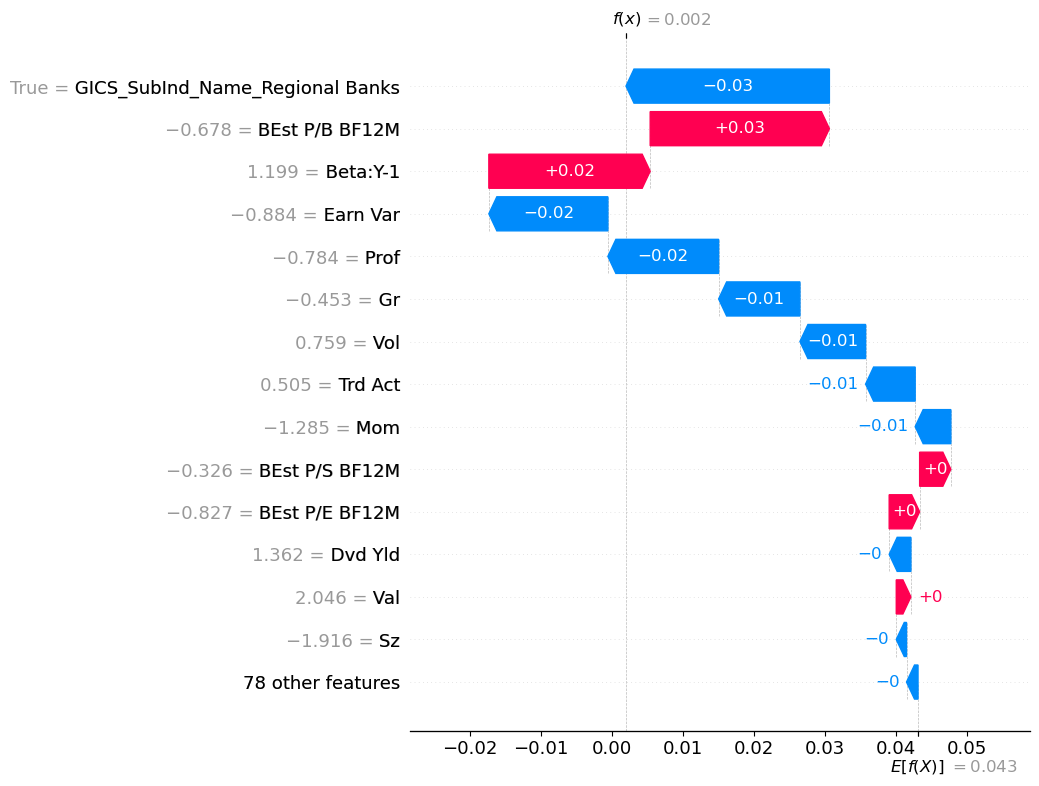

In [9]:
# Waterfall for the largest unexpected LOSS
plot_stock_waterfall(loss_index, title_suffix="(largest unexpected LOSS)")


Waterfall for VST_202401 (largest unexpected GAIN)


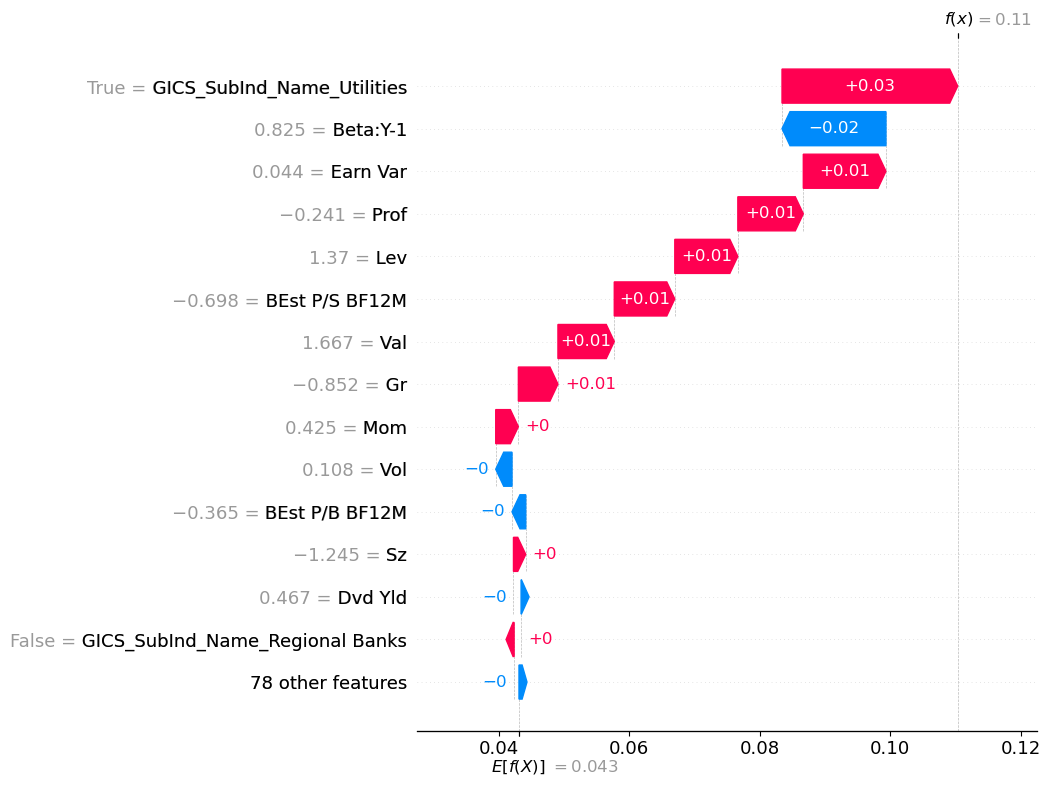

In [10]:
# Waterfall for the largest unexpected GAIN
plot_stock_waterfall(gain_index, title_suffix="(largest unexpected GAIN)")

#### **PACW vs VST Post-Mortem Analyses**

Based on the results:

- **Largest unexpected loss:**  
  - `Ticker_Date:` **PACW_202301**  
  - `Ticker:` PACW (PacWest Bancorp)  
  - `Date:` 202301  
  - `ActualRet:` **−0.5439**  
  - `ExpectedRet:` **+0.0020**  
  - `UnexpectedGain:` **−0.5459**

- **Largest unexpected gain:**  
  - `Ticker_Date:` **VST_202401**  
  - `Ticker:` VST (Vistra Corp)  
  - `Date:` 202401  
  - `ActualRet:` **+0.7955**  
  - `ExpectedRet:` **+0.1104**  
  - `UnexpectedGain:` **+0.6852**

---

<font color="blue"><b>1. Unexpected loss: PACW_202301 (PacWest Bancorp)</b></font>

**Part A – What the model "knew" (from the waterfall plot)**

For PACW in 2023-01:

- The **baseline** model expectation for a generic stock is **+4.3%** (`E[f(X)] = 0.043`).
- The waterfall pushes the prediction **sharply down** to a final **f(x) = 0.2%** — essentially zero expected return. The model is clearly skeptical of this name.
- The main **positive contributors** (red, pushing right) are:
  - Cheap **BEst P/B BF12M = −0.678** adding **+3 percentage points**. The model likes that the bank screens inexpensive on price-to-book.
  - High **Beta:Y-1 = 1.199** adding **+2 points**, reflecting the global rule that high-beta names earn higher returns.
  - **Val = 2.046** adds a tiny positive push (+0pp rounded) — the stock screens as deeply "cheap" on value.
  - **BEst P/S BF12M = −0.326** and **BEst P/E BF12M = −0.827** each add negligible positive contributions.
- The main **negative contributors** (blue, pushing left) are:
  - **GICS_SubInd_Name_Regional Banks = True** — the single largest negative at **−3 percentage points**. The model has learned that regional banks carry a structural penalty.
  - **Earn Var = −0.884** subtracts **−2 points** — low/negative earnings variability in a distressed bank is penalized.
  - **Prof = −0.784** subtracts **−2 points** — very weak profitability.
  - **Gr = −0.453** subtracts **−1 point** — negative growth.
  - **Vol = 0.759** subtracts **−1 point** — elevated idiosyncratic volatility.
  - **Trd Act = 0.505** subtracts **−1 point** — above-average trading activity.
  - **Mom = −1.285** subtracts **−1 point** — negative momentum, the stock has been falling.
  - **Dvd Yld = 1.362**, **Sz = −1.916**, and 78 other features each contribute small negative pushes.

Net result: the model reads PACW as **a cheap but deeply troubled regional bank** — the Regional Banks penalty, poor profitability, negative momentum, and weak growth overwhelm the cheap valuation and high beta. The prediction lands at essentially **zero expected return (+0.2%)**, far below the baseline. The model is more bearish on PACW than the consolidated notebook's version (+1.2%), which is actually a better read of the situation.

**Part B – What actually happened (news that the model missed)**

In reality, PACW was one of the regional banks caught up in the **2023 U.S. banking crisis**. After the collapse of Silicon Valley Bank and Signature Bank in March 2023, regional lenders suffered heavy deposit outflows, rating downgrades, and intense short-selling. PacWest's shares lost roughly [85–90% of their value from early March to early May 2023](https://www.pymnts.com/news/banking/2023/pacwest-bancorp-reportedly-considering-options-as-stock-price-plummets), and at several points markets openly questioned whether the bank would survive as an independent institution.

The factor set only sees **pre-crisis financial ratios and historical risk measures**. It does **not** directly capture:

- Real-time deposit runs and liquidity stress  
- Social-media-driven loss of confidence  
- Regulatory actions, emergency funding lines, or merger talks  

So the model ends up **near-zero but not negative**, while the stock actually drops more than **54%** in the one-month `FwdRet` window. That gap of about **−54.6% UnexpectedGain** is exactly the kind of **tail-risk shock** a PM needs to manage with stress tests, scenario analysis, and position-size / hedging decisions outside the factor model.

---

<font color="blue"><b>2. Unexpected gain: VST_202401 (Vistra Corp)</b></font>

**Part A – What the model "knew" (from the waterfall plot)**

For VST in 2024-01:

- The baseline is **+4.3%**.
- The waterfall pushes the prediction **well above baseline** to a final **f(x) = 11.0%** — the model is meaningfully bullish on this name.
- The most visible **positive contributors** (red, pushing right) are:
  - **GICS_SubInd_Name_Utilities = True** — the single largest positive at **+3 percentage points**. The model has learned that utilities are being re-rated in this regime.
  - **Earn Var = 0.044** adds **+1 point** — near-average earnings variability contributes positively.
  - **Prof = −0.241** adds **+1 point** — the model reads this profitability level favorably.
  - **Lev = 1.37** adds **+1 point** — above-average leverage is rewarded (geared upside).
  - **BEst P/S BF12M = −0.698** adds **+1 point** — cheap on price-to-sales.
  - **Val = 1.667** adds **+1 point** — attractively valued.
  - **Gr = −0.852** adds **+1 point** — interestingly, the model reads this negative growth signal as a positive contributor, possibly capturing a mean-reversion or re-rating effect.
  - **Mom = 0.425**, **Sz = −1.245**, and **GICS_SubInd_Name_Regional Banks = False** each add tiny positive pushes.
- The main **negative contributor** (blue, pushing left) is:
  - **Beta:Y-1 = 0.825** — subtracts **−2 points**. Vistra's below-market beta means the model's strong "higher beta = higher returns" rule works against it here.
  - **Vol = 0.108**, **BEst P/B BF12M = −0.365**, **Dvd Yld = 0.467**, and 78 other features contribute small negative pushes.

Taken together, the model sees VST as **a re-rating utility with attractive valuation, decent leverage, and a sector tailwind**, deserving a **double-digit expected return (~11%)**. The only meaningful headwind is below-market beta. This is a more bullish read than the consolidated notebook's version (+8.1%), reflecting the model's stronger conviction on utilities in this regime.

**Part B – What actually happened (news that the model missed)**

According to [Business Insider](https://markets.businessinsider.com/news/stocks/best-performing-sp500-stock-utility-vistra-energy-ai-power-electricity-2024-10), Vistra became one of the **best-performing stocks in the S&P 500 in 2024**, with the share price roughly tripling over the year and trading alongside the top AI-related winners.

Key drivers that appear in the news, but **not directly as explicit features in the factor set**, include:

- A structural **surge in electricity demand from AI data centers and cloud computing**, which sharply increased the value of flexible power generation.  
- The build-out of a **zero-carbon, nuclear-heavy fleet** via the acquisition of **Energy Harbor**, giving Vistra a large competitive nuclear portfolio.  
- Upward revisions to **earnings and cash-flow expectations**, plus large **share-repurchase programs and asset acquisitions** that repositioned the stock from "boring utility" to "strategic AI-power infrastructure."

Those are narrative- and regime-driven catalysts. In the SHAP waterfall they show up only indirectly through the Utilities sector premium, slightly better value, leverage, and earnings features. The model therefore moves the expected one-month return up to **about +11%**, while the realized return is almost **+80%**.

The approximately **+68.5% UnexpectedGain** is a strong example of positive alpha created by structural change and thematic positioning, not just traditional factor tilts. The model correctly identified VST as an above-average opportunity (11% vs. 4.3% baseline) but could not predict the magnitude of the AI-driven power demand shock.

---

> **Key takeaway:** The PM dashboard separates what the model *can* explain (factor-driven expected returns) from what it *cannot* (news-driven surprises). PACW's −54.6% unexpected loss was a tail-risk event (banking crisis) that no backward-looking factor model could foresee. VST's +68.5% unexpected gain was a structural regime shift (AI power demand) that the model partially captured through its sector premium but massively underestimated. The "Unexpected Gain" column is the PM's alpha hunting list — it shows where human judgment, news monitoring, and scenario analysis must supplement the factor model.

In [11]:
# ============================================================== EOF ========================================================================